## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
df = pd.read_csv("/content/gdrive/MyDrive/STAT3013/Dataset/data_cleaned.csv")
df["volume_category"] = pd.Categorical(df["volume_category"],
    categories=["Low","Moderate","High"], ordered=True)

ALPHA = 0.05
print(f"Loaded: {df.shape[0]} rows")
print(df["nutrition_category"].value_counts())

Loaded: 198 rows
nutrition_category
Surplus    6
Deficit    4
Name: count, dtype: int64


## 1. Subgroup 1 — Nutrition: Surplus vs None
**Câu hỏi:** Dinh dưỡng có làm thay đổi mức hypertrophy không?

**H0:** Mean hedges_g của Surplus = None
**H1:** Dinh dưỡng có làm thay đổi mức hypertrophy

In [4]:
surplus = df[df["nutrition_category"] == "Surplus"]["hedges_g"].dropna()
deficit = df[df["nutrition_category"] == "Deficit"]["hedges_g"].dropna()
none_n  = df[df["nutrition_category"] == "None"]["hedges_g"].dropna()

print(f"Surplus: n={len(surplus)}, mean={surplus.mean():.4f}, SD={surplus.std():.4f}")
print(f"Deficit: n={len(deficit)}, mean={deficit.mean():.4f}, SD={deficit.std():.4f}")
print(f"None:    n={len(none_n)},  mean={none_n.mean():.4f},  SD={none_n.std():.4f}")

Surplus: n=6, mean=0.3333, SD=0.2505
Deficit: n=4, mean=0.0138, SD=0.0871
None:    n=0,  mean=nan,  SD=nan


In [5]:
# Levene + t-test: Surplus vs None
print("\n--- Levene\'s Test (Surplus vs None) ---")
print(stats.levene(surplus, none_n, center="median"))

print("\n--- Welch t-test (Surplus vs None) ---")
print(stats.ttest_ind(surplus, none_n, equal_var=False))


--- Levene's Test (Surplus vs None) ---
LeveneResult(statistic=np.float64(nan), pvalue=np.float64(nan))

--- Welch t-test (Surplus vs None) ---
TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))


/tmp/ipykernel_2234/2568781737.py:3: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print(stats.levene(surplus, none_n, center="median"))
/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [6]:
# ANOVA nếu có đủ nhóm (Surplus / Deficit / None)
valid = [g for g in [surplus, deficit, none_n] if len(g) > 1]
if len(valid) >= 3:
    print("\n--- One-way ANOVA (Surplus / Deficit / None) ---")
    print(stats.f_oneway(*valid))
else:
    print("\nDeficit group quá nhỏ — chỉ so sánh Surplus vs None")


Deficit group quá nhỏ — chỉ so sánh Surplus vs None


/tmp/ipykernel_2234/1397224729.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True)


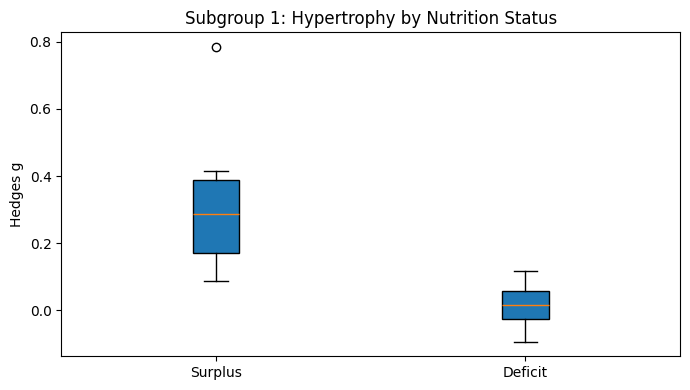

Saved: fig_sub1_nutrition.png


In [7]:
# Visualize
fig, ax = plt.subplots(figsize=(7, 4))
data   = [g for g in [surplus, none_n, deficit] if len(g) > 1]
labels = [l for l, g in zip(["Surplus","None","Deficit"],[surplus,none_n,deficit]) if len(g) > 1]
ax.boxplot(data, labels=labels, patch_artist=True)
ax.set_ylabel("Hedges g")
ax.set_title("Subgroup 1: Hypertrophy by Nutrition Status")
plt.tight_layout()
plt.savefig("/content/gdrive/MyDrive/STAT3013/fig_sub1_nutrition.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_sub1_nutrition.png")

## 2. Subgroup 2 — Failure vs Non-failure
**Câu hỏi:** Tập đến failure có cho kết quả hypertrophy tốt hơn không khi kiểm soát volume?

**H0:** Mean hedges_g của Failure = Non-failure
**H1:** Tập đến failure cho kết quả khác

In [8]:
fail_1 = df[df["failure_binary"] == 1]["hedges_g"].dropna()
fail_0 = df[df["failure_binary"] == 0]["hedges_g"].dropna()

print(f"Failure:     n={len(fail_1)}, mean={fail_1.mean():.4f}, SD={fail_1.std():.4f}")
print(f"Non-failure: n={len(fail_0)}, mean={fail_0.mean():.4f}, SD={fail_0.std():.4f}")

print("\n--- Levene\'s Test ---")
print(stats.levene(fail_1, fail_0, center="median"))

print("\n--- Welch t-test (Failure vs Non-failure) ---")
print(stats.ttest_ind(fail_1, fail_0, equal_var=False))

Failure:     n=159, mean=0.4173, SD=0.3689
Non-failure: n=39, mean=0.4771, SD=0.3743

--- Levene's Test ---
LeveneResult(statistic=np.float64(0.007314324250202335), pvalue=np.float64(0.9319322557435665))

--- Welch t-test (Failure vs Non-failure) ---
TtestResult(statistic=np.float64(-0.8968689084870839), pvalue=np.float64(0.37352960614198494), df=np.float64(57.485323211000555))


In [9]:
# Failure effect WITHIN each volume group
print("--- Failure effect within each volume group ---")
for cat in ["Low", "Moderate", "High"]:
    sub = df[df["volume_category"] == cat]
    f1  = sub[sub["failure_binary"] == 1]["hedges_g"].dropna()
    f0  = sub[sub["failure_binary"] == 0]["hedges_g"].dropna()
    if len(f1) > 1 and len(f0) > 1:
        t_r = stats.ttest_ind(f1, f0, equal_var=False)
        sig = "*" if t_r.pvalue < ALPHA else "ns"
        print(f"  {cat}: failure={f1.mean():.4f}, non-failure={f0.mean():.4f}, p={t_r.pvalue:.4f} {sig}")
    else:
        print(f"  {cat}: insufficient data (failure n={len(f1)}, non-failure n={len(f0)})")

--- Failure effect within each volume group ---
  Low: failure=0.1526, non-failure=0.8180, p=0.0004 *
  Moderate: failure=0.3643, non-failure=0.3519, p=0.9061 ns
  High: failure=0.5965, non-failure=0.3390, p=0.0008 *


/tmp/ipykernel_2234/3542551460.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True)
/tmp/ipykernel_2234/3542551460.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True)
/tmp/ipykernel_2234/3542551460.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True)


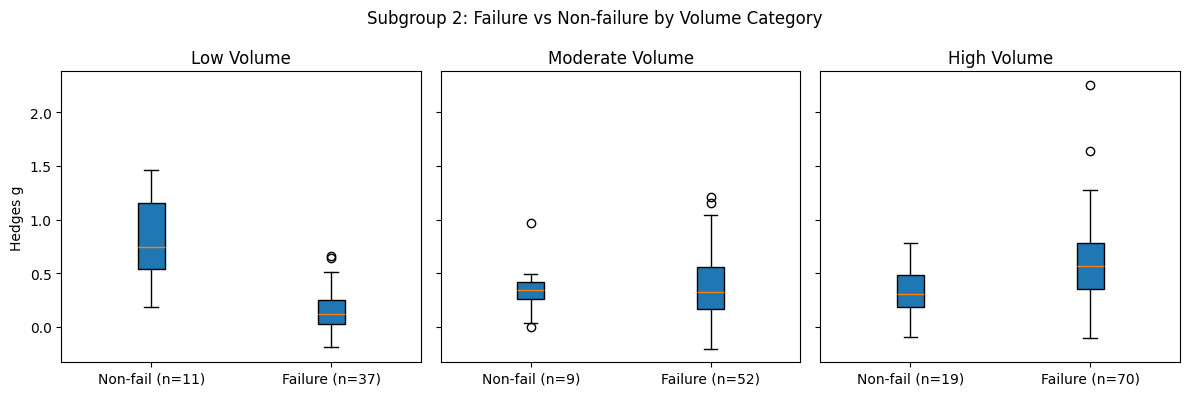

Saved: fig_sub2_failure_by_volume.png


In [11]:
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, cat in zip(axes, ["Low", "Moderate", "High"]):
    sub = df[df["volume_category"] == cat]
    f1  = sub[sub["failure_binary"] == 1]["hedges_g"].dropna()
    f0  = sub[sub["failure_binary"] == 0]["hedges_g"].dropna()
    data, labels = [], []
    if len(f0) > 0: data.append(f0); labels.append(f"Non-fail (n={len(f0)})")
    if len(f1) > 0: data.append(f1); labels.append(f"Failure (n={len(f1)})")
    if data:
        ax.boxplot(data, labels=labels, patch_artist=True)
    ax.set_title(f"{cat} Volume")
    ax.set_ylabel("Hedges g" if cat == "Low" else "")
fig.suptitle("Subgroup 2: Failure vs Non-failure by Volume Category", fontsize=12)
plt.tight_layout()
plt.savefig("/content/gdrive/MyDrive/STAT3013/fig_sub2_failure_by_volume.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_sub2_failure_by_volume.png")

## 3. Subgroup 3 — Upper vs Lower Body
**Câu hỏi:** Cơ trên hay cơ dưới phản ứng tốt hơn với cùng mức training volume?

**H0:** Mean hedges_g của Upper = Lower
**H1:** Cơ trên và cơ dưới phản ứng khác nhau với volume

In [12]:
upper = df[df["upper.lower"] == "upper"]["hedges_g"].dropna()
lower = df[df["upper.lower"] == "lower"]["hedges_g"].dropna()

print(f"Upper: n={len(upper)}, mean={upper.mean():.4f}, SD={upper.std():.4f}")
print(f"Lower: n={len(lower)}, mean={lower.mean():.4f}, SD={lower.std():.4f}")

print("\n--- Levene\'s Test ---")
print(stats.levene(upper, lower, center="median"))

print("\n--- Welch t-test (Upper vs Lower body) ---")
print(stats.ttest_ind(upper, lower, equal_var=False))

Upper: n=74, mean=0.4528, SD=0.3408
Lower: n=124, mean=0.4149, SD=0.3867

--- Levene's Test ---
LeveneResult(statistic=np.float64(3.029240335531375), pvalue=np.float64(0.08334571431070277))

--- Welch t-test (Upper vs Lower body) ---
TtestResult(statistic=np.float64(0.7208964315794522), pvalue=np.float64(0.471968999784125), df=np.float64(169.04565705117807))


## 4. Subgroup 4 — Experience Level
**Câu hỏi:** Người có nhiều kinh nghiệm tập có mức hypertrophy thấp hơn (diminishing returns) không?

**H0:** Mean hedges_g bằng nhau giữa các nhóm kinh nghiệm
**H1:** Người nhiều kinh nghiệm có g khác biệt

In [13]:
# Chia experience thành 3 nhóm — FIX: không dùng \n trong label
df["exp_group"] = pd.cut(df["years.exp"],
    bins=[0, 1, 3, 100],
    labels=["Beginner(<1yr)", "Intermediate(1-3yr)", "Advanced(>3yr)"])

print("Experience groups:")
print(df["exp_group"].value_counts().sort_index())

Experience groups:
exp_group
Beginner(<1yr)           2
Intermediate(1-3yr)     20
Advanced(>3yr)         176
Name: count, dtype: int64


In [14]:
g_beg  = df[df["exp_group"] == "Beginner(<1yr)"]["hedges_g"].dropna()
g_int  = df[df["exp_group"] == "Intermediate(1-3yr)"]["hedges_g"].dropna()
g_adv  = df[df["exp_group"] == "Advanced(>3yr)"]["hedges_g"].dropna()

print(f"Beginner:     n={len(g_beg)}, mean={g_beg.mean():.4f}")
print(f"Intermediate: n={len(g_int)}, mean={g_int.mean():.4f}")
print(f"Advanced:     n={len(g_adv)}, mean={g_adv.mean():.4f}")

valid = [g for g in [g_beg, g_int, g_adv] if len(g) > 1]
if len(valid) >= 2:
    print("\n--- One-way ANOVA (Experience groups) ---")
    print(stats.f_oneway(*valid))

Beginner:     n=2, mean=-0.1648
Intermediate: n=20, mean=0.3094
Advanced:     n=176, mean=0.4494

--- One-way ANOVA (Experience groups) ---
F_onewayResult(statistic=np.float64(4.011805348932335), pvalue=np.float64(0.01961490680213652))


## 5. Summary — Kết luận toàn bộ Subgroup

In [15]:
t_nutr = stats.ttest_ind(surplus, none_n, equal_var=False)
t_fail = stats.ttest_ind(fail_1, fail_0, equal_var=False)
t_ul   = stats.ttest_ind(upper, lower, equal_var=False)

print("="*55)
print("SUBGROUP ANALYSIS SUMMARY")
print("="*55)
results = {
    "Nutrition (Surplus vs None)":       t_nutr.pvalue,
    "Failure (Failure vs Non-failure)":  t_fail.pvalue,
    "Body Region (Upper vs Lower)":      t_ul.pvalue,
}
for label, p_val in results.items():
    sig = "REJECT H0 *" if p_val < ALPHA else "fail to reject H0"
    print(f"  {label}: p={p_val:.4f} -> {sig}")

print()
print("FILES SAVED:")
print("  fig_sub1_nutrition.png")
print("  fig_sub2_failure_by_volume.png")

SUBGROUP ANALYSIS SUMMARY
  Nutrition (Surplus vs None): p=nan -> fail to reject H0
  Failure (Failure vs Non-failure): p=0.3735 -> fail to reject H0
  Body Region (Upper vs Lower): p=0.4720 -> fail to reject H0

FILES SAVED:
  fig_sub1_nutrition.png
  fig_sub2_failure_by_volume.png


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
